# 📊 Notebook 01 — Data Exploration & EDA
Hourly Energy Consumption Project

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_raw_data, clean_data, add_time_features

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# ── Load data ──
# Change filename to match what you downloaded from Kaggle
df_raw = load_raw_data('../data/raw/AEP_hourly.csv')
df = clean_data(df_raw)
df = add_time_features(df)
df.head()

✅ Loaded 121,273 rows from AEP_hourly.csv
   Date range: 2004-10-01 01:00:00 → 2018-08-03 00:00:00
✅ Cleaned data: 121,010 rows remaining
✅ Time features added


,AEP_MW,hour,day_of_week,month,year,is_weekend,quarter,hour_sin,hour_cos,month_sin,month_cos
Datetime,,,,,,,,,,,
2004-10-01 01:00:00,12379.0,1,4,10,2004,0,4,0.258819,0.965926,-0.866025,0.5
2004-10-01 02:00:00,11935.0,2,4,10,2004,0,4,0.500000,0.866025,-0.866025,0.5
2004-10-01 03:00:00,11692.0,3,4,10,2004,0,4,0.707107,0.707107,-0.866025,0.5
2004-10-01 04:00:00,11597.0,4,4,10,2004,0,4,0.866025,0.500000,-0.866025,0.5
2004-10-01 05:00:00,11681.0,5,4,10,2004,0,4,0.965926,0.258819,-0.866025,0.5


In [ ]:
# ── Basic stats ──
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDescriptive stats:')
df.describe()

Shape: (121010, 11)

Missing values:
AEP_MW         0
hour           0
day_of_week    0
month          0
year           0
is_weekend     0
quarter        0
hour_sin       0
hour_cos       0
month_sin      0
month_cos      0
dtype: int64

Descriptive stats:


,AEP_MW,hour,day_of_week,month,year,is_weekend,quarter,hour_sin,hour_cos,month_sin,month_cos
count,121010.000000,121010.000000,121010.000000,121010.000000,121010.000000,121010.000000,121010.000000,1.210100e+05,1.210100e+05,1.210100e+05,1.210100e+05
mean,15481.789331,11.493926,3.001281,6.501636,2011.176043,0.286191,2.503248,9.169192e-04,5.123999e-04,6.570410e-03,1.233862e-03
std,2565.037890,6.924580,2.000456,3.462477,4.011216,0.451982,1.122592,7.068691e-01,7.073494e-01,7.025181e-01,7.116403e-01
min,9581.000000,0.000000,0.000000,1.000000,2004.000000,0.000000,1.000000,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,13626.250000,5.000000,1.000000,4.000000,2008.000000,0.000000,2.000000,-7.071068e-01,-7.071068e-01,-5.000000e-01,-8.660254e-01
50%,15303.000000,11.000000,3.000000,6.000000,2011.000000,0.000000,2.000000,1.224647e-16,6.123234e-17,1.224647e-16,6.123234e-17
75%,17186.000000,17.000000,5.000000,10.000000,2015.000000,1.000000,4.000000,7.071068e-01,7.071068e-01,5.000000e-01,8.660254e-01
max,23271.000000,23.000000,6.000000,12.000000,2018.000000,1.000000,4.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


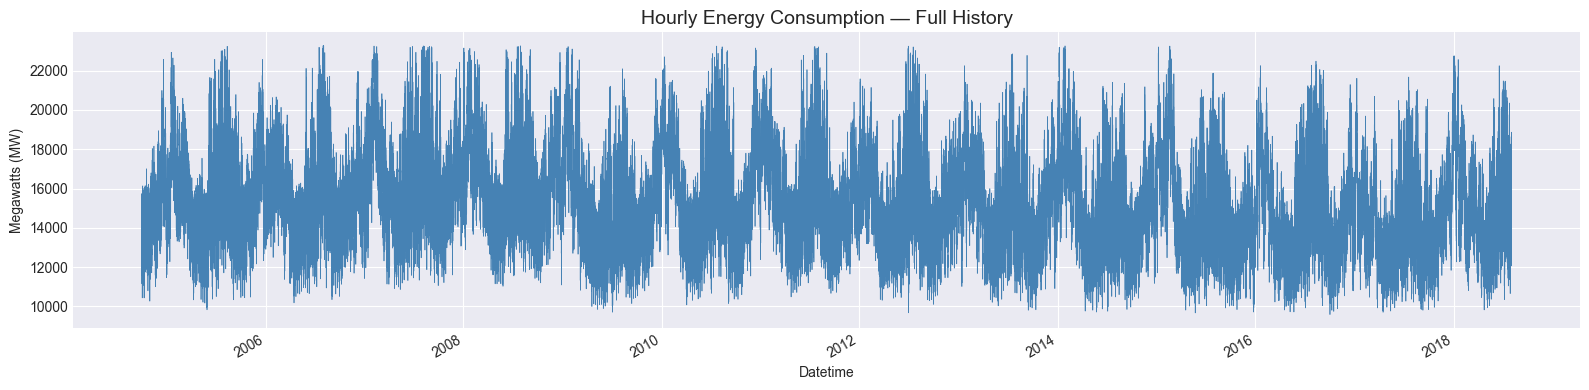

In [7]:
# ── Plot 1: Full time series ──
fig, ax = plt.subplots(figsize=(16, 4))
df.iloc[:, 0].plot(ax=ax, linewidth=0.5, color='steelblue')
ax.set_title('Hourly Energy Consumption — Full History', fontsize=14)
ax.set_ylabel('Megawatts (MW)')
plt.tight_layout()
plt.savefig('../data/processed/01_full_timeseries.png', dpi=150)
plt.show()

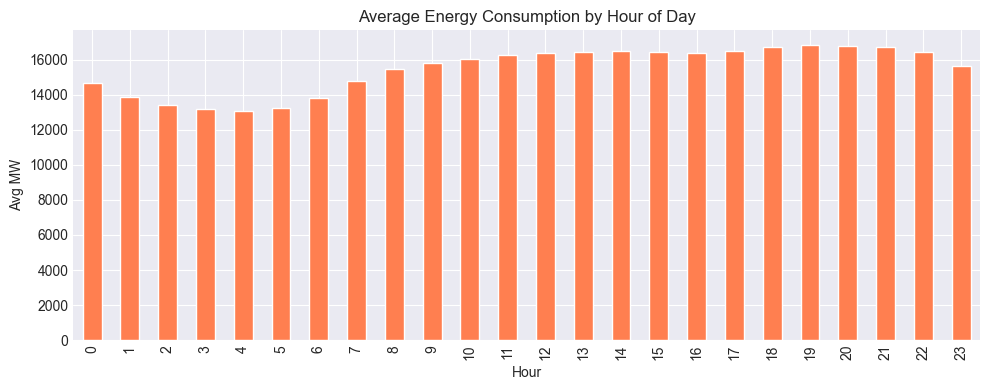

In [8]:
# ── Plot 2: Average by hour of day ──
energy_col = df.columns[0]
hourly_avg = df.groupby('hour')[energy_col].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_avg.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Average Energy Consumption by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg MW')
plt.tight_layout()
plt.savefig('../data/processed/02_hourly_avg.png', dpi=150)
plt.show()

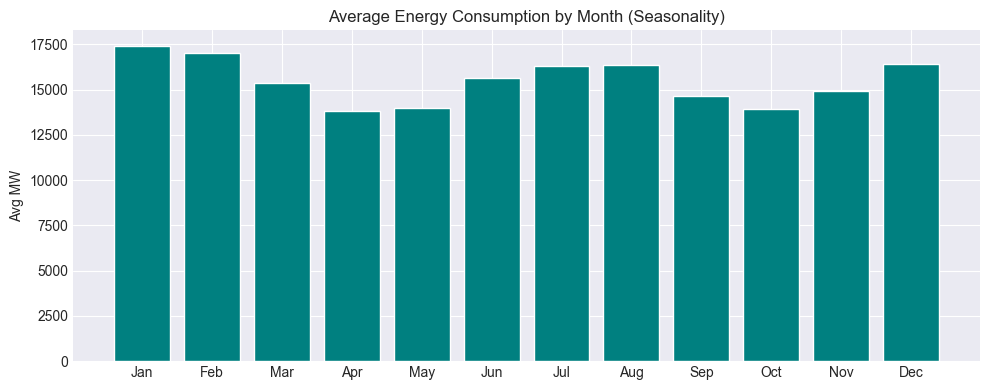

In [9]:
# ── Plot 3: Monthly seasonality ──
monthly_avg = df.groupby('month')[energy_col].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(months, monthly_avg.values, color='teal', edgecolor='white')
ax.set_title('Average Energy Consumption by Month (Seasonality)')
ax.set_ylabel('Avg MW')
plt.tight_layout()
plt.savefig('../data/processed/03_monthly_seasonality.png', dpi=150)
plt.show()

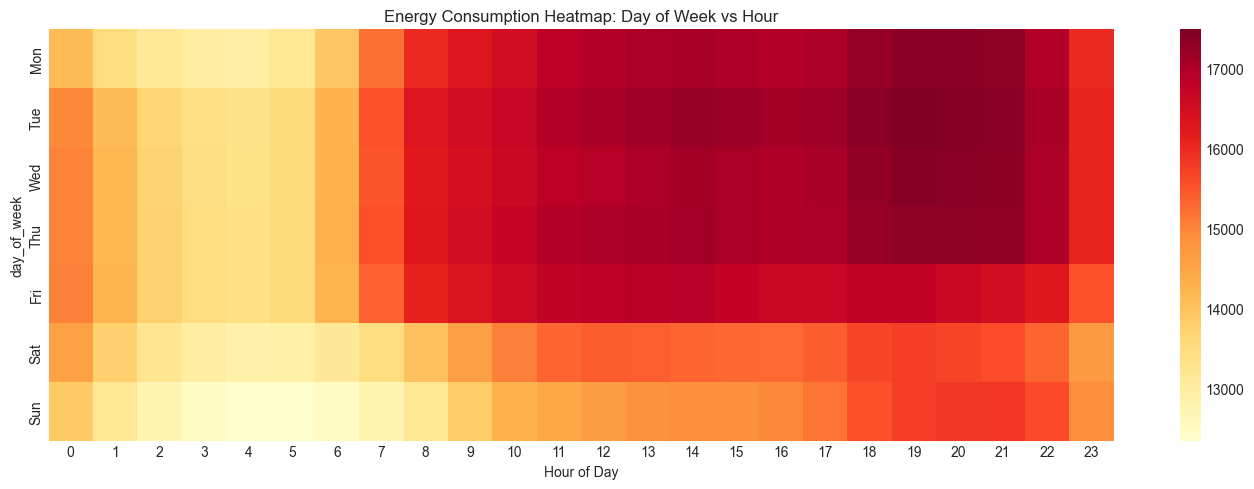

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
0,14123.771468,13505.170360,13147.864266,12978.572022,12961.196676,13206.944598,13944.995845,15193.063712,16003.626907,16308.805825,...,17079.460251,17001.485315,16936.027933,17006.574825,17238.199721,17374.432961,17369.022253,17307.781944,16958.798890,16013.427978
1,14948.608033,14151.436288,13679.530471,13424.313019,13346.765928,13544.324100,14264.642659,15526.443828,16310.993056,16532.168056,...,17210.211699,17168.050139,17086.500697,17149.794406,17364.979079,17485.171071,17443.981919,17394.110957,17046.750347,16092.299169
2,15006.961219,14203.652355,13717.897507,13455.530471,13366.408587,13552.459834,14261.026316,15496.599168,16239.055633,16450.018056,...,17088.730181,17036.509777,16968.504895,17046.997195,17271.600840,17411.582402,17388.788889,17338.433333,17021.626389,16094.914127
3,15011.500000,14209.391967,13735.576177,13476.555402,13391.067961,13586.290859,14297.182825,15544.319001,16275.479050,16507.449093,...,17104.849372,17035.123077,16964.259777,17017.560224,17205.216783,17320.400838,17317.152990,17287.554167,16988.420833,16088.494460
4,15019.061026,14222.157895,13742.657895,13480.034626,13393.472299,13574.217452,14225.080444,15370.140669,16110.924581,16360.051676,...,16876.080668,16762.530070,16655.881450,16670.991632,16789.813370,16789.506944,16630.687933,16508.744799,16268.183079,15533.414127
5,14559.299169,13758.242382,13263.547091,12984.572022,12849.027701,12872.885042,13117.329640,13505.022161,14015.501385,14602.192521,...,15335.975069,15277.295014,15275.072022,15400.585873,15649.587258,15741.022161,15672.472299,15586.171745,15335.246537,14696.736842
6,13889.649584,13190.297784,12739.608146,12475.016949,12358.824100,12346.628809,12493.828255,12756.087258,13204.184211,13834.155125,...,14864.387812,14871.641274,14942.047091,15157.785319,15544.277008,15754.440443,15820.605263,15853.592798,15600.537396,14908.872576


In [11]:
# ── Plot 4: Heatmap — Hour vs Day of Week ──
heatmap_data = df.groupby(['day_of_week', 'hour'])[energy_col].mean().unstack()
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, yticklabels=day_labels)
ax.set_title('Energy Consumption Heatmap: Day of Week vs Hour')
ax.set_xlabel('Hour of Day')
plt.tight_layout()
plt.savefig('../data/processed/04_heatmap.png', dpi=150)
plt.show()

df.groupby(['day_of_week', 'hour'])[energy_col].mean().unstack()

In [12]:
# ── Save processed data ──
df.to_csv('../data/processed/energy_cleaned.csv')
print('✅ Saved cleaned data to data/processed/energy_cleaned.csv')

✅ Saved cleaned data to data/processed/energy_cleaned.csv
